# Staggered difference-in-differences

**How can researchers identify the dynamic causal effect of policy interventions when different units adopt the treatment at different times without falling into the forbidden-comparison trap of textbook two-way fixed effects?**
Did a policy work, when different units adopted it in different years? When
treatment timing is *staggered*, the textbook two-way fixed-effects (TWFE)
regression uses already-treated units as controls, which can contaminate the
estimate when effects vary across cohorts or exposure lengths. We plant a known effect in a
**simulated** staggered panel and recover it with the heterogeneity-robust estimators in
`puremacro.did`: **Callaway-Sant'Anna** group-time ATTs, aggregated with cohort-size weights,
and the **Sun-Abraham** interaction-weighted event study. No real data are used; everything
runs in the browser.

## The method in math

**Setting.** Unit $i$ is first treated at calendar time $G_i = g$ (its *cohort*); units that
are never treated have $G_i=\infty$. Potential outcomes are $Y_{it}(0)$ (untreated path) and
$Y_{it}(g)$ (treated-at-$g$ path); we only ever see one of them.

**The TWFE pitfall.** The default applied specification regresses
$$ Y_{it} = \alpha_i + \lambda_t + \beta\,D_{it} + \varepsilon_{it}, \qquad
D_{it}=\mathbb{1}\{t \ge G_i\}, $$
and reads $\hat\beta$ as "the" treatment effect. **Goodman-Bacon (2021)** shows $\hat\beta$ is
a weighted average of *all* possible $2\times2$ DiD comparisons — including **forbidden** ones
that use *already-treated* units as the control group. The weights on these comparisons
are nonnegative, but comparisons that subtract a changing treatment effect can be biased.
When written as weights on the underlying treatment effects, some weights can be negative:
$\hat\beta$ can have the wrong sign even when every unit's true effect is positive.

**Callaway-Sant'Anna (2021).** Sidestep the regression. Define a clean **group-time ATT** for
cohort $g$ at time $t$, differenced off the cohort's last pre-treatment period $g-1$ and a
*never-treated* (or not-yet-treated) control set $C$:
$$ \text{ATT}(g,t)=\mathbb{E}\!\left[Y_t-Y_{g-1}\mid G=g\right]
-\mathbb{E}\!\left[Y_t-Y_{g-1}\mid C\right]. $$
The first term is the cohort's own change from base period $g-1$ to $t$; the second nets out the
control group's change over the same window, leaving the causal effect.

**Aggregation weights.** CS weight every summary by **cohort size**. With $n_g$ units in cohort
$g$ and $\mathcal{G}_e$ the cohorts observed $e$ periods after adoption, the event-study profile
(their eq. 3.4) and the recommended overall summary (eqs. 3.7 and 3.11) are
$$ \theta_{es}(e)=\sum_{g\in\mathcal{G}_e}\frac{n_g}{\sum_{g'\in\mathcal{G}_e} n_{g'}}\,\text{ATT}(g,g+e),
\qquad \theta^O_{sel}=\sum_g \frac{n_g}{\sum_{g'} n_{g'}}\,\theta_{sel}(g),\quad
\theta_{sel}(g)=\frac{1}{T-g+1}\sum_{t\ge g}\text{ATT}(g,t). $$
$\theta^O_{sel}$ first averages each cohort over its own post-treatment periods, then weights the
cohorts by size. The alternative $\theta^O_W$ (eq. 3.10) averages all post-treatment cells with
cohort-size weights, so it leans towards early cohorts, which contribute more cells.
`callaway_santanna` reports $\theta^O_{sel}$ as `att_overall`, and every other summary in
`overall_aggregations`.

**Sun-Abraham (2021).** Repair the *dynamic* TWFE event study instead: estimate
cohort$\times$relative-time effects $\text{CATT}(g,e)$ in a regression fully interacted in cohort
and relative time, then average them at each $e$ with the sample shares of the cohorts observed
there (their eq. 27). Without covariates and with never-treated controls, this
interaction-weighted estimator **coincides with Callaway-Sant'Anna** (SA, p. 24): the same
$\text{ATT}(g,t)$ cells with the same cohort-size weights, so $\text{ATT}_{\text{SA}}(e)=\theta_{es}(e)$.
The two event studies below are therefore identical. In puremacro the headline numbers differ only
because the default overall summaries differ: `sun_abraham` reports $\theta^O_W$,
`callaway_santanna` reports $\theta^O_{sel}$.

### Baseline Calibration

| Symbol | Economic / Econometric Role | Baseline Setting | Units |
|---|---|---|---|
| $G_i$ | Treatment adoption cohort (calendar time) | $\{5, 8, 11, \infty\}$, each drawn with probability 1/4 | Time index ($t$) |
| $D_{it}$ | Binary treatment indicator ($\mathbb{1}\{t \ge G_i\}$) | Staggered rollout | Binary $\{0, 1\}$ |
| $\text{ATT}$ | True planted Average Treatment Effect on Treated | Constant $+1.0$ | Outcome units |
| $N$ | Number of cross-sectional units in panel | $90$ (cohort sizes printed below) | Cross-sectional units |
| $T$ | Number of panel time periods | $14$ | Time periods |
| $e$ | Relative event time ($t - G_i$) | $-10, \dots, +9$ | Relative periods |
| $\sigma$ | Idiosyncratic noise s.d. | $0.3$ | Outcome units |
| $n_{\text{boot}}$ | Panel bootstrap replications (whole units resampled) | $400$ | Bootstrap draws |

**Intuition.** The bias is about *forbidden comparisons*. A late-adopting cohort, differenced
against an early-adopting cohort that is *already* treated, attributes the early cohort's
ongoing dynamic response to the late cohort — with a sign that can flip the headline. CS and SA
restrict every comparison to a *clean* control (never-treated or not-yet-treated) and a *fixed*
pre-period $g-1$, then aggregate with weights you can read off. The event-study profile they
report is the dynamic ATT by horizon $e$ *since* treatment: how the effect builds (or fades) after
switch-on. The weights answer "whose effect?": $\theta^O_{sel}$ is the average effect experienced by
the units that ever took the treatment, which is how CS (p. 18) motivate it as the analogue of the
$2\times2$ ATT.

### Seminal Literature Citations

- Callaway, B., & Sant'Anna, P. H. (2021). Difference-in-differences with multiple time periods. *Journal of Econometrics*, 225(2), 200–230. Equation and page numbers here follow arXiv:1803.09015v4.
- de Chaisemartin, C., & D'Haultfœuille, X. (2020). Two-way fixed effects estimators with heterogeneous treatment effects. *American Economic Review*, 110(9), 2964–2996.
- Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing. *Journal of Econometrics*, 225(2), 254–277.
- Sun, L., & Abraham, S. (2021). Estimating dynamic treatment effects in event studies with heterogeneous treatment effects. *Journal of Econometrics*, 225(2), 175–199. Equation and page numbers here follow arXiv:1804.05785.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.did import (
    callaway_santanna, sun_abraham,
    CallawaySantannaResult, SunAbrahamResult,
)

## 1. A simulated staggered-adoption panel with a known ATT
Three cohorts are first treated at t = 5, 8, 11; a fourth group is never
treated. The DGP is two-way fixed effects with parallel pre-trends and a
*constant* treatment kick `tau = +1.0`, so the true event-study profile is
flat at +1 from event time 0 onward.

In [2]:
rng = np.random.default_rng(20240529)

N_UNITS, T = 90, 14
COHORTS = (5, 8, 11, np.nan)          # three treated cohorts + never-treated
TRUE_ATT, SIGMA = 1.0, 0.3

assign = rng.choice(len(COHORTS), size=N_UNITS, replace=True)
unit_fe = rng.standard_normal(N_UNITS)
time_fe = rng.standard_normal(T) * 0.3

rows = []
for i in range(N_UNITS):
    g = COHORTS[assign[i]]
    for t in range(1, T + 1):
        treated = 1.0 if (not pd.isna(g)) and t >= g else 0.0
        y = unit_fe[i] + time_fe[t - 1] + TRUE_ATT * treated + SIGMA * rng.standard_normal()
        rows.append({"unit": i, "time": t, "y": y, "treat_time": g})
panel = pd.DataFrame(rows)

first = panel.groupby("unit")["treat_time"].first()
n_g = first.value_counts()                       # cohort sizes n_g (treated cohorts only)
n_never = int(first.isna().sum())
print(f"Panel: {N_UNITS} units x {T} periods; planted ATT = {TRUE_ATT:+.1f}")
print("cohort sizes: " + ", ".join(f"g={int(g)}: {n}" for g, n in n_g.sort_index().items())
      + f", never treated: {n_never}")

Panel: 90 units x 14 periods; planted ATT = +1.0
cohort sizes: g=5: 25, g=8: 27, g=11: 25, never treated: 13


**Intuition.** This is the cleanest possible world for the estimators: parallel pre-trends
(the only thing separating units before treatment is the fixed effect `unit_fe`), a genuine
never-treated control group, and a homogeneous effect. Sampling noise still separates
the estimate from `+1.0`; recovery is approximate. The never-treated group is what lets
Callaway-Sant'Anna avoid the forbidden already-treated comparisons entirely. Cohort sizes
are random, so the cohort-size weights are not exactly equal.

## 2. Two heterogeneity-robust estimators on the same panel
`callaway_santanna` builds the group-time ATT(g,t) matrix off never-treated
controls, aggregates it with cohort-size weights and bootstraps whole units; `sun_abraham`
reuses the *same* cells and bootstrap draws. The constant, homogeneous effect used here also
permits valid TWFE estimation; this section checks recovery, and the final exposure-growth exercise shows TWFE failing.

In [3]:
cs = callaway_santanna(panel, unit="unit", time="time", outcome="y",
                       treat_time="treat_time", n_boot=400, alpha=0.10, seed=0)
sa = sun_abraham(panel, unit="unit", time="time", outcome="y",
                 treat_time="treat_time", n_boot=400, alpha=0.10, seed=0)

assert isinstance(cs, CallawaySantannaResult)
assert isinstance(sa, SunAbrahamResult)

print(cs.summary())
print(sa.summary())

Callaway-Sant'Anna result
  group-time ATTs   : 42
  event-study rows  : 20
  overall ATT       : +1.1379  (se 0.0772, 90% CI [+1.0053, +1.2581])
  aggregation       : group

Sun-Abraham result
  group-time ATTs   : 42
  event-study rows  : 20
  overall ATT       : +1.1292  (se 0.0741, 90% CI [+1.0073, +1.2512])
  aggregation       : simple



## 3. Recovery and aggregation checks (asserts on headline numbers)
The planted effect is the independent check: the aggregate ATT must be close to it. The
aggregation formulas are then recomputed by hand from the library's own ATT(g, t) cells and the
cohort sizes. That is an internal check: it tests the weights, not the cells. The base period
(event time -1) is the normalization point (exactly 0); and every post-treatment horizon tracks
the constant +1.0.

In [4]:
es_cs = cs.att_event_study.sort_values("event_time").reset_index(drop=True)
es_sa = sa.att_event_study.sort_values("event_time").reset_index(drop=True)

assert abs(cs.att_overall - TRUE_ATT) < 0.25, cs.att_overall
assert abs(sa.att_overall - TRUE_ATT) < 0.25, sa.att_overall

# The CS summaries by hand, from the ATT(g, t) cells and the cohort sizes n_g.
gt_post = cs.att_gt[cs.att_gt["event_time"] >= 0].assign(n=lambda d: d["g"].map(n_g))
theta_sel_g = gt_post.groupby("g")["att"].mean()                                  # eq. 3.7
theta_O_sel = np.average(theta_sel_g, weights=n_g.reindex(theta_sel_g.index))    # eq. 3.11
theta_O_W = np.average(gt_post["att"], weights=gt_post["n"])                     # eq. 3.10
assert np.isclose(cs.att_overall, theta_O_sel)   # CS default: theta^O_sel
assert np.isclose(sa.att_overall, theta_O_W)     # SA default: theta^O_W
# SA's interaction-weighted event study is CS eq. 3.4 (SA p. 24): same cells, weights and draws.
assert np.array_equal(es_cs["event_time"], es_sa["event_time"])
assert np.allclose(es_cs[["att", "se"]], es_sa[["att", "se"]], rtol=0, atol=1e-12)

# The overall interval is the bootstrap distribution of the aggregate itself. Averaging
# the event-study CI endpoints would ignore their dependence and use different weights.
lo_overall, hi_overall = cs.att_overall_lo, cs.att_overall_hi
assert lo_overall < cs.att_overall < hi_overall

# Base period (event_time == -1) is the normalization point: exactly 0.
base = es_cs[es_cs["event_time"] == -1]
assert len(base) == 1 and abs(float(base["att"].iloc[0])) < 1e-12
leads = es_cs[es_cs["event_time"] < -1]
assert not leads.empty and np.isfinite(leads[["att", "se", "lo", "hi"]]).all().all()
assert (leads["se"] > 0).all()  # genuine estimated leads, unlike the normalized base

# Every post-treatment horizon tracks the constant true effect.
post = es_cs[es_cs["event_time"] >= 0]
for _, r in post.iterrows():
    assert abs(r["att"] - TRUE_ATT) < 0.40, (r["event_time"], r["att"])

w_sel = n_g.sort_index() / n_g.sum()
print("theta^O_sel cohort weights: " + ", ".join(f"g={int(g)}: {w:.3f}" for g, w in w_sel.items()))
print(f"CS overall ATT (theta^O_sel, eq. 3.11) = {cs.att_overall:+.3f}   se {cs.att_overall_se:.3f}"
      f"   90% CI [{lo_overall:+.3f}, {hi_overall:+.3f}]")
print(f"SA overall ATT (theta^O_W,   eq. 3.10) = {sa.att_overall:+.3f}   se {sa.att_overall_se:.3f}"
      f"   90% CI [{sa.att_overall_lo:+.3f}, {sa.att_overall_hi:+.3f}]")
print(f"true ATT = {TRUE_ATT:+.3f}; does the CS interval contain it? {lo_overall <= TRUE_ATT <= hi_overall}")
oa = cs.overall_aggregations.set_index("aggregation").loc[["group", "simple", "dynamic", "calendar"]]
print("all CS overall summaries:\n" + oa[["att", "se", "lo", "hi"]].round(3).to_string())
print(f"max |CS - SA| over the event study: att {np.abs(es_cs['att'] - es_sa['att']).max():.1e}, "
      f"se {np.abs(es_cs['se'] - es_sa['se']).max():.1e}")

theta^O_sel cohort weights: g=5: 0.325, g=8: 0.351, g=11: 0.325
CS overall ATT (theta^O_sel, eq. 3.11) = +1.138   se 0.077   90% CI [+1.005, +1.258]
SA overall ATT (theta^O_W,   eq. 3.10) = +1.129   se 0.074   90% CI [+1.007, +1.251]
true ATT = +1.000; does the CS interval contain it? False
all CS overall summaries:
               att     se     lo     hi
aggregation                            
group        1.138  0.077  1.005  1.258
simple       1.129  0.074  1.002  1.249
dynamic      1.130  0.083  0.991  1.263
calendar     1.117  0.068  1.005  1.226
max |CS - SA| over the event study: att 0.0e+00, se 0.0e+00


**Read the output.** Both estimators land near the planted `+1.0`. The cohort weights are
0.325, 0.351 and 0.325 because the random cohort sizes are 25, 27 and 25. The CS overall ATT
($\theta^O_{sel}$) is `+1.138` with a 90% bootstrap interval of `[+1.005, +1.258]`. Its lower
end sits just above the truth, so this realization misses it. Nominal coverage is a
repeated-sampling property, not a guarantee for every dataset, and finite-sample bootstrap
coverage is approximate. Never choose a seed to force coverage, and never average pointwise
interval endpoints to obtain an aggregate interval.

SA reports `+1.129` because its default summary is $\theta^O_W$, which weights cells rather
than cohorts. It is not a different weighting of cohorts: the two event studies are
identical (difference `0.0e+00` in both the estimates and the standard errors), as SA state they
should be. Their intervals differ slightly in construction: CS reports percentile intervals,
SA normal ones, $\pm z\,\text{se}$. That is why SA's `[+1.007, +1.251]` is not the `simple` row
of the CS table, `[1.002, 1.249]`.

The **post-treatment profile** is flat up to noise: every `event_time >= 0` estimate lies within
0.40 of `+1.0` (the assert above), with no build-up or decay, as planted. The **`event_time = -1` coefficient is exactly 0** *by
construction*, not because a pre-trend test passed. Earlier periods are genuine estimated
leads relative to $g-1$ and can be inspected for departures from parallel trends. Their
pointwise bands are not a simultaneous pre-trend test, and failure to reject does not prove
parallel trends.

### Hero figure — the event study
Estimates jump from the normalized 0 at the base period to the true +1.0 line
and stay nearby; earlier leads fluctuate around zero. Shading gives pointwise
90% panel-bootstrap intervals, not simultaneous coverage of the entire curve.

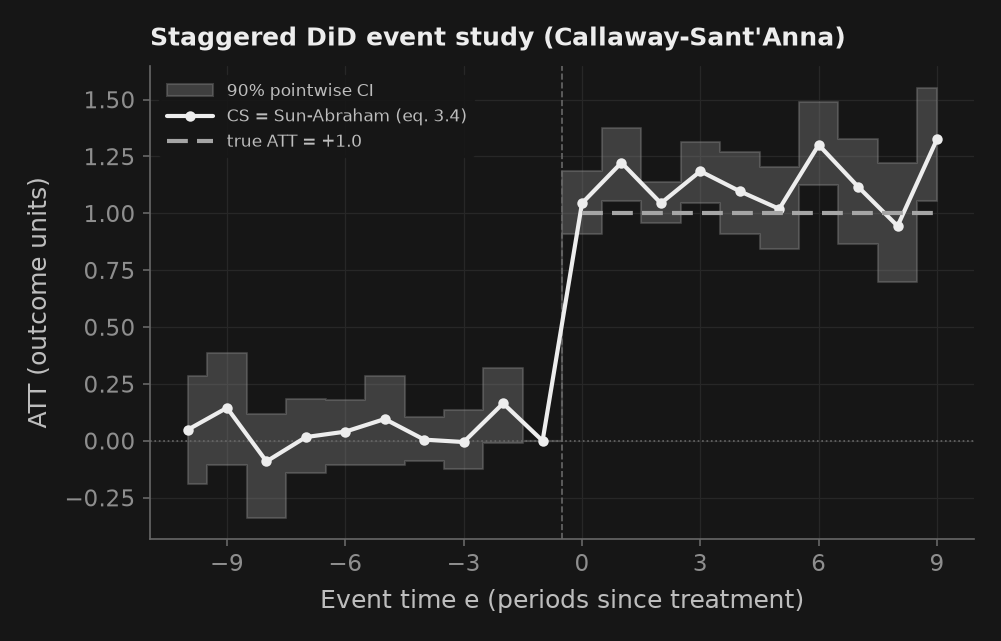

In [5]:
es = es_cs
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax.fill_between(es["event_time"], es["lo"], es["hi"], color=_nbstyle.NOTA, alpha=0.35,
                step="mid", label="90% pointwise CI")
ax.plot(es["event_time"], es["att"], **_nbstyle.S1, marker="o", markersize=4,
        label="CS = Sun-Abraham (eq. 3.4)")
post_e = es[es["event_time"] >= 0]
ax.plot(post_e["event_time"], [TRUE_ATT] * len(post_e), **_nbstyle.S2,
        label=f"true ATT = {TRUE_ATT:+.1f}")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Event time e (periods since treatment)")
ax.set_ylabel("ATT (outcome units)")
ax.set_title("Staggered DiD event study (Callaway-Sant'Anna)")
ax.legend(loc="upper left", fontsize=8)

### Supporting — which overall ATT?
The same ATT(g, t) cells give four overall summaries (CS eqs. 3.10-3.12), each with its own
bootstrap interval. $\theta^O_{sel}$ is the `callaway_santanna` default and $\theta^O_W$ the
`sun_abraham` default. With a homogeneous effect all four target the same +1.0.

Text(0.0, 1.0, 'Four overall summaries of the same ATT(g, t) cells')

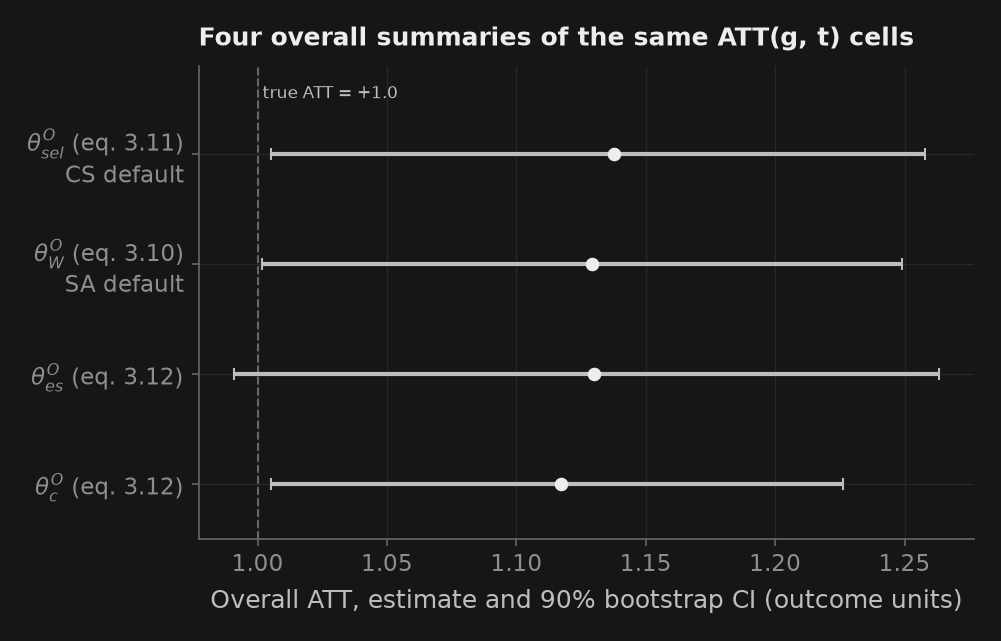

In [6]:
names = {"group": "$\\theta^O_{sel}$ (eq. 3.11)\nCS default",
         "simple": "$\\theta^O_W$ (eq. 3.10)\nSA default",
         "dynamic": "$\\theta^O_{es}$ (eq. 3.12)", "calendar": "$\\theta^O_c$ (eq. 3.12)"}
ypos = np.arange(len(oa))[::-1]
fig, ax = _nbstyle.figura()
ax.axvline(TRUE_ATT, color=_nbstyle.SPINE, linewidth=1.0, linestyle="--")
ax.text(TRUE_ATT, len(oa) - 0.45, f" true ATT = {TRUE_ATT:+.1f}", ha="left", va="center",
        color=_nbstyle.TEXTO, fontsize=8)
ax.errorbar(oa["att"], ypos, xerr=[oa["att"] - oa["lo"], oa["hi"] - oa["att"]],
            fmt="o", color=_nbstyle.TINTA, ecolor=_nbstyle.TEXTO, capsize=3)
ax.set_yticks(ypos, [names[a] for a in oa.index])
ax.set_ylim(-0.5, len(oa) - 0.2)
ax.set_xlabel("Overall ATT, estimate and 90% bootstrap CI (outcome units)")
ax.set_title("Four overall summaries of the same ATT(g, t) cells")

### Supporting — the underlying group-time effects
Each cohort's post-treatment ATT(g, t) hovers around +1.0 (dashed), while its earlier
leads fluctuate around zero. At each event time, the event study (eq. 3.4) is the
cohort-size-weighted average of the cohorts observed there; the legend gives each $n_g$.

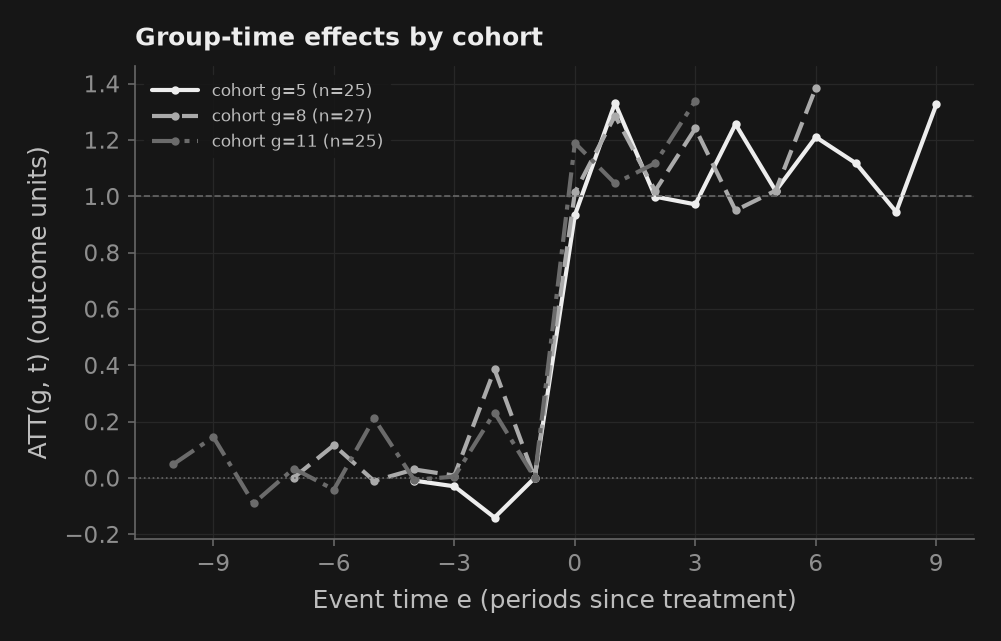

In [7]:
fig, ax = _nbstyle.figura()
gt = cs.att_gt
cohorts = sorted(gt["g"].unique())
stys = _nbstyle.styles(len(cohorts))
ccols = _nbstyle.palette(len(cohorts))
for c, color, sty in zip(cohorts, ccols, stys):
    sub = gt[gt["g"] == c].sort_values("event_time")
    ax.plot(sub["event_time"], sub["att"], marker="o", markersize=3,
            color=color, linestyle=sty, label=f"cohort g={int(c)} (n={n_g[c]})")
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axhline(TRUE_ATT, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_xlabel("Event time e (periods since treatment)")
ax.set_ylabel("ATT(g, t) (outcome units)")
ax.set_title("Group-time effects by cohort")
ax.legend(loc="upper left", fontsize=8)

**Read the output.** The summaries figure shows the four overall ATTs between `1.117`
(calendar) and `1.138` (group), with overlapping intervals: with a homogeneous effect they
estimate the same number and differ only in how they weight the same noisy cells. In this draw
only the $\theta^O_{es}$ interval, `[0.991, 1.263]`, contains the truth; the four intervals share
the same bootstrap draws, so they tend to miss together. The group-time figure exposes the
machinery. Every cohort's
$\text{ATT}(g,t)$ curve orbits the dashed `+1.0` line after treatment, and the event-study point
at each horizon is their cohort-size-weighted average at that elapsed time. Only cohort 5 is
observed beyond $e = 6$, so the right tail of the event study is one cohort's curve, with wider
bands. The weights start to matter when effects differ across cohorts or grow with exposure:
then the summaries answer different questions, and TWFE answers none of them (see *Your turn*).

## Your turn — when does TWFE break? Effects that grow with exposure

Section 1 planted a constant kick, the one case where static TWFE works. Now let the effect grow
with exposure: $\tau(e) = 1 + \text{slope}\cdot e$ for $e = t - g \ge 0$. `simulate_dynamic`
redraws section 1's panel with the same seed and the same draws and also stores `D` and the
planted `tau`. The planted target is $\theta^O_{sel}$ computed from `tau` and the realized
cohort sizes. Each estimator is run twice, on the noisy panel and on the noise-free outcome
$y = \tau$; the second run separates what an estimator *targets* from sampling noise.

**Predict first:** as the slope rises, does static TWFE track the planted target? In which
direction does it miss when the effect *fades* (a negative slope)?

In [8]:
def simulate_dynamic(slope, cohorts=COHORTS):
    """Section 1's panel with tau(e) = TRUE_ATT + slope*e for e = t - g >= 0.

    Same seed and draws as section 1, so slope = 0 reproduces `panel`.
    """
    rng = np.random.default_rng(20240529)
    assign = rng.choice(len(cohorts), size=N_UNITS, replace=True)
    unit_fe = rng.standard_normal(N_UNITS)
    time_fe = rng.standard_normal(T) * 0.3
    rows = []
    for i in range(N_UNITS):
        g = cohorts[assign[i]]
        for t in range(1, T + 1):
            on = (not pd.isna(g)) and t >= g
            tau = TRUE_ATT + slope * (t - g) if on else 0.0
            y = unit_fe[i] + time_fe[t - 1] + tau + SIGMA * rng.standard_normal()
            rows.append({"unit": i, "time": t, "y": y, "treat_time": g,
                         "D": float(on), "tau": tau})
    return pd.DataFrame(rows)


def twfe(df, col="y"):
    """Static TWFE coefficient on D (exact two-way demeaning; balanced panel)."""
    dm = {c: (df[c] - df.groupby("unit")[c].transform("mean")
              - df.groupby("time")[c].transform("mean") + df[c].mean()).to_numpy()
          for c in (col, "D")}
    return float(dm["D"] @ dm[col] / (dm["D"] @ dm["D"]))


# ← Change this: growth of the effect per period of exposure (try 0, 0.2, 0.4 or -0.2; range -0.3 to 1.0).
SLOPE_YOU = 0.4

p_you = simulate_dynamic(SLOPE_YOU)
assert np.allclose(simulate_dynamic(0.0)["y"], panel["y"])   # slope 0 is section 1's panel

# Planted target: theta^O_sel from the planted tau(g, t) cells and the cohort sizes n_g.
cells = p_you[p_you["D"] == 1].groupby(["treat_time", "time"])["tau"].first()
theta_g = cells.groupby(level="treat_time").mean()
truth = float(np.average(theta_g, weights=n_g.reindex(theta_g.index)))

cs_you = callaway_santanna(p_you, n_boot=0)
cs_nf = callaway_santanna(p_you.assign(y=p_you["tau"]), n_boot=0)   # noise-free: y = tau
tw, tw_nf = twfe(p_you), twfe(p_you, "tau")

print(f"slope {SLOPE_YOU:+.2f}: planted theta^O_sel = {truth:+.3f}")
print(f"  noise-free y = tau : CS {cs_nf.att_overall:+.3f}   static TWFE {tw_nf:+.3f}")
print(f"  noisy panel        : CS {cs_you.att_overall:+.3f}   static TWFE {tw:+.3f}")
other = cs_nf.overall_aggregations.set_index("aggregation")["att"]
print("  other CS summaries, noise-free: "
      + ", ".join(f"{a} {other[a]:+.3f}" for a in ("simple", "dynamic", "calendar")))

# 1. On noise-free data CS reproduces the planted theta^O_sel exactly: eq. 3.11 weights.
assert np.isclose(cs_nf.att_overall, truth), (cs_nf.att_overall, truth)
# 2. With noise, the CS error is section 1's error: the estimate is linear in y and its
#    weights do not depend on y, so the slope moves estimate and target one for one.
assert np.isclose(cs_you.att_overall - truth, cs.att_overall - TRUE_ATT)
# 3. Static TWFE misses in the direction of the slope: it understates effects that grow
#    and overstates effects that fade, and is exact only when the effect is constant.
assert np.sign(round(truth - tw_nf, 9)) == np.sign(SLOPE_YOU), (truth, tw_nf)

slope +0.40: planted theta^O_sel = +2.200
  noise-free y = tau : CS +2.200   static TWFE +1.314
  noisy panel        : CS +2.338   static TWFE +1.371
  other CS summaries, noise-free: simple +2.367, dynamic +2.800, calendar +2.133


**Prompts.**

1. *Basic.* Set `SLOPE_YOU = 0`. Before running, predict whether static TWFE hits the planted
   effect on the noise-free panel. It should: with a constant effect, the forbidden comparisons
   subtract an already-treated cohort whose effect no longer changes.
2. *Intermediate.* Run 0.2 and then 0.4. Does the TWFE gap grow in proportion to the slope? Use
   Goodman-Bacon's forbidden comparisons to explain its direction: in the $2\times2$ that treats
   cohort 11 against the already-treated cohort 5, cohort 5's effect keeps growing, and that growth
   is subtracted as if it were a control trend. Then read the other printed summaries. Why is
   $\theta^O_W$ (`simple`) above $\theta^O_{sel}$ when effects grow, and why is $\theta^O_{es}$
   (`dynamic`) higher still? (Which cohort alone identifies the long event times?) All three are
   valid estimands that answer different questions; TWFE is not one of them.
3. *Stretch.* Remove the never-treated group with
   `simulate_dynamic(slope, cohorts=(5, 8, 11))`. (a) Call `callaway_santanna` with the default
   control, read the error, and switch to `control="not_yet_treated"`. (b) Compute TWFE's implicit
   weights on treated observations by Frisch-Waugh-Lovell: two-way demean `D` to get $\tilde D$ and
   set $w_{it} = \tilde D_{it} D_{it} / \sum \tilde D D$. Assert that the weights sum to 1, that
   `(w * tau).sum()` equals `twfe(p, "tau")`, and that some treated cells get negative weight.
   Which cohort and which event times are they, and why are the long-exposure cells of the
   earliest cohort penalized? (c) Predict, then sweep the slope over 0, 0.4 and 2.5; at 2.5 assert
   that the noise-free TWFE is negative although every planted effect is at least 1. (d) Which
   post-treatment cells can CS identify with not-yet-treated controls (cohort 5 through $e=5$,
   cohort 8 through $e=2$, cohort 11 none)? Check that on $y=\tau$ its `att_overall` equals the
   cohort-size-weighted mean of the identified cells' cohort averages, and compare it with the
   full-panel target. That gap is what a missing clean control group costs.

**How comprehensive is this?** `puremacro.did` is a full modern staggered-DiD toolkit:
alongside `callaway_santanna` (with `aggregation=` "group", "simple", "dynamic" or "calendar")
and `sun_abraham` it ships the `borusyak_jaravel_spiess` (2024) imputation estimator,
`cdh_did` (de Chaisemartin-D'Haultfoeuille 2020) switchers estimator, `honest_did` sensitivity
bounds (pass `sigma=cs.event_study_vcov` for the full bootstrap covariance), and
`synthetic_did` / `sdid_multi_cohort` (Arkhangelsky et al. 2021) — all on the same
`(unit, time, outcome, treat_time)` long panel. Notebook 15 reaches the same event study with
local projections (LP-DiD), and notebook 29 covers synthetic DiD with a single treated unit.